## Data Loading & Preparation
The raw dataset contains player records from FIFA 15 through FC 24 stacked in a single file. 
Below we filter to FC 24 only, investigate a dtype warning in the `gk` column, and inspect 
the full column list to plan which columns to drop.

In [2]:
import os
print(os.getcwd())
print(os.listdir('..'))

C:\Users\USER\fc24-player-analytics-ml
['.copilot', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.packettracer', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'Cisco Packet Tracer 9.0.0', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'fc24-player-analytics-ml', 'housing.csv', 'housing_dataset.csv', 'IRIS.csv', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{8de63440-7cd9-11f1-8c58-cc16c6986e53}.TM.blf', 'NTUSER.DAT{8de63440-7cd9-11f1-8c58-cc16c6986e53}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{8de63440-7cd9-11f1-8c58-cc16c6986e53}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'react-projects', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'user.json', 'Videos']


In [5]:
df.groupby('fifa_version')['fifa_update'].nunique()


fifa_version
15.0    1
16.0    1
17.0    1
18.0    1
19.0    1
20.0    1
21.0    1
22.0    1
23.0    1
24.0    1
Name: fifa_update, dtype: int64

In [6]:
df_fc24 = df[df['fifa_version'] == 24].copy()
print(df_fc24.shape)

(18350, 109)


In [7]:
df_fc24['gk'].unique()[:20]


array(['18+3', '19+3', '21+3', '88+2', '20+3', '16+3', '87+3', '87+2',
       '22+3', '86+3', '86+2', '85+3', '17+3', '85+2', '19+2', '18+2',
       '84+2', '17+2', '14+3', '83+3'], dtype=object)

In [8]:
[c for c in df_fc24.columns if 'gk' in c.lower()]

['gk']

In [9]:
df_fc24.columns.tolist()


['player_id',
 'player_url',
 'fifa_version',
 'fifa_update',
 'update_as_of',
 'short_name',
 'long_name',
 'player_positions',
 'overall',
 'potential',
 'value_eur',
 'wage_eur',
 'age',
 'dob',
 'height_cm',
 'weight_kg',
 'club_team_id',
 'club_name',
 'league_id',
 'league_name',
 'league_level',
 'club_position',
 'club_jersey_number',
 'club_loaned_from',
 'club_joined_date',
 'club_contract_valid_until_year',
 'nationality_id',
 'nationality_name',
 'nation_team_id',
 'nation_position',
 'nation_jersey_number',
 'preferred_foot',
 'weak_foot',
 'skill_moves',
 'international_reputation',
 'work_rate',
 'body_type',
 'real_face',
 'release_clause_eur',
 'player_tags',
 'player_traits',
 'pace',
 'shooting',
 'passing',
 'dribbling',
 'defending',
 'physic',
 'attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_co

The dataset contains 26 position-rating columns (`ls`, `st`, `cam`, `gk`, etc.) stored as 
strings like `"88+2"` (base rating + chemistry bonus) — redundant with `overall` and 
`player_positions`, and not useful as numeric features without extensive parsing. These, 
along with identifier/URL/image columns and league/club metadata, are dropped below.

In [10]:
drop_cols = [
    'player_id', 'player_url', 'fifa_version', 'fifa_update', 'update_as_of',
    'long_name', 'dob',  # keep short_name only, as a label — not a feature
    'club_team_id', 'club_name', 'league_id', 'league_name', 'league_level',
    'club_position', 'club_jersey_number', 'club_loaned_from',
    'club_joined_date', 'club_contract_valid_until_year',
    'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position',
    'nation_jersey_number', 'player_tags', 'player_traits', 'body_type', 'real_face',
    # the 26 position-rating columns (the "88+2" string format)
    'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram',
    'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb',
    'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk'
]
df_clean = df_fc24.drop(columns=drop_cols)
print(df_clean.shape)

(18350, 56)


In [11]:
df_clean.isnull().sum().sort_values(ascending=False).head(15)


goalkeeping_speed     16305
physic                 2045
shooting               2045
passing                2045
dribbling              2045
pace                   2045
defending              2045
release_clause_eur     1280
value_eur               100
wage_eur                 87
height_cm                 0
age                       0
player_positions          0
short_name                0
overall                   0
dtype: int64

In [12]:
df_clean['player_positions'].unique()[:15]

<StringArray>
[     'ST, LW',          'ST',     'CM, CAM',     'CF, CAM',      'CF, ST',
          'GK',          'LW',     'CDM, CM',          'CB',         'CDM',
          'RW',      'CM, RW', 'CDM, RB, CM',      'ST, CF',     'CAM, CM']
Length: 15, dtype: str

In [13]:
df_clean.isnull().sum().sort_values(ascending=False).head(15)


goalkeeping_speed     16305
physic                 2045
shooting               2045
passing                2045
dribbling              2045
pace                   2045
defending              2045
release_clause_eur     1280
value_eur               100
wage_eur                 87
height_cm                 0
age                       0
player_positions          0
short_name                0
overall                   0
dtype: int64

In [17]:
for col in ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']:
    df_clean[col] = df_clean[col].fillna(0)

In [18]:
df_clean['goalkeeping_speed'] = df_clean['goalkeeping_speed'].fillna(0)

In [19]:
df_clean = df_clean.drop(columns=['release_clause_eur'])


In [20]:
df_clean = df_clean.dropna(subset=['value_eur'])

In [21]:
df_clean['wage_eur'] = df_clean['wage_eur'].fillna(df_clean['wage_eur'].median())

In [22]:
print(df_clean.shape)
print(df_clean.isnull().sum().sum()) 


(18250, 55)
0


In [23]:
def map_position(pos_string):
    primary = pos_string.split(',')[0].strip()
    forward = ['ST', 'CF', 'LW', 'RW', 'LF', 'RF']
    midfield = ['CM', 'CAM', 'CDM', 'LM', 'RM', 'LAM', 'RAM', 'LDM', 'RDM', 'LCM', 'RCM']
    defense = ['CB', 'LB', 'RB', 'LWB', 'RWB', 'LCB', 'RCB']
    if primary == 'GK':
        return 'Goalkeeper'
    elif primary in forward:
        return 'Forward'
    elif primary in midfield:
        return 'Midfielder'
    elif primary in defense:
        return 'Defender'
    else:
        return 'Unknown'

df_clean['position_group'] = df_clean['player_positions'].apply(map_position)
df_clean['position_group'].value_counts()

position_group
Midfielder    6636
Defender      6143
Forward       3438
Goalkeeper    2033
Name: count, dtype: int64

In [42]:
print("Dataset shape:", df_clean.shape)
print("\nData types:\n", df_clean.dtypes.value_counts())
print("\nMissing values (top 10):\n", df_clean.isnull().sum().sort_values(ascending=False).head(10))
print("\nTarget distribution (position_group):\n", df_clean['position_group'].value_counts())

Dataset shape: (18250, 56)

Data types:
 int64      41
float64    10
str         5
Name: count, dtype: int64

Missing values (top 10):
 short_name          0
player_positions    0
overall             0
potential           0
value_eur           0
wage_eur            0
age                 0
height_cm           0
weight_kg           0
preferred_foot      0
dtype: int64

Target distribution (position_group):
 position_group
Midfielder    6636
Defender      6143
Forward       3438
Goalkeeper    2033
Name: count, dtype: int64


### Dataset Audit Summary

After filtering to FC 24 and dropping 53 redundant/identifier columns, the working dataset 
contains **18,250 players and 56 columns** (55 original features plus the engineered 
`position_group` classification target). Missing values were limited to attributes that 
are structurally exclusive by player role (goalkeeping stats for outfield players and vice 
versa), plus a small number of missing `value_eur`, `wage_eur`, and `release_clause_eur` 
entries, all handled during cleaning above. The classification target (`position_group`) is 
moderately imbalanced: Midfielders (6,636) and Defenders (6,143) are the largest classes, 
Forwards (3,438) and Goalkeepers (2,033) are smaller.

In [24]:
print(df_clean.shape)
print(df_clean.isnull().sum().sum())  # confirm 0

df_clean.to_csv('data/players_fc24_clean.csv', index=False)

(18250, 56)
0


In [27]:
df = pd.read_csv('data/players_fc24_clean.csv')
df.shape


(18250, 56)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

df = pd.read_csv('data/players_fc24_clean.csv')  # no ../ needed
df.shape

(18250, 56)

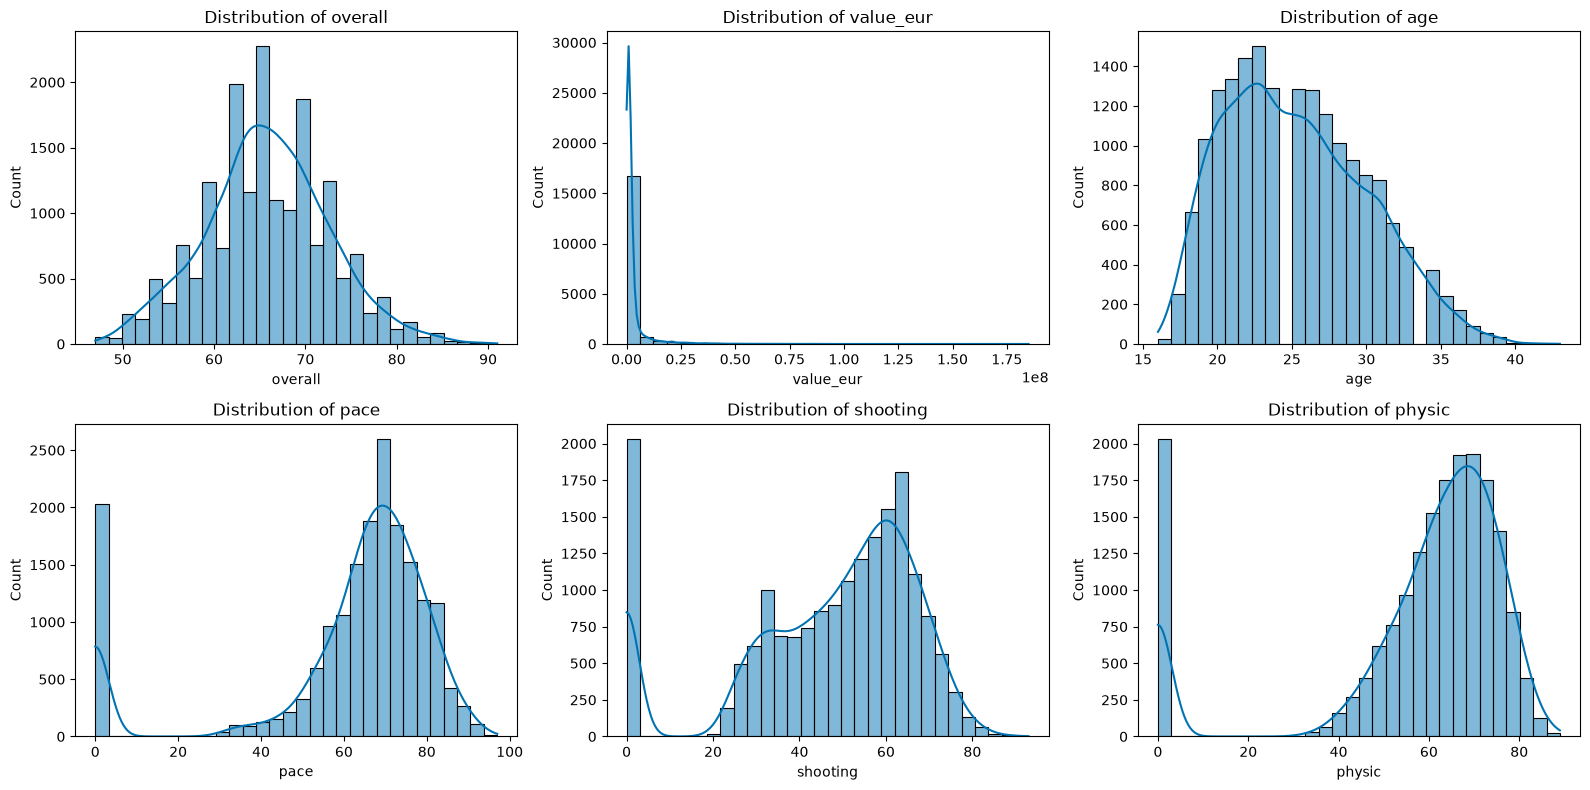

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_plot = ['overall', 'value_eur', 'age', 'pace', 'shooting', 'physic']

for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.histplot(df[col], bins=30, ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()


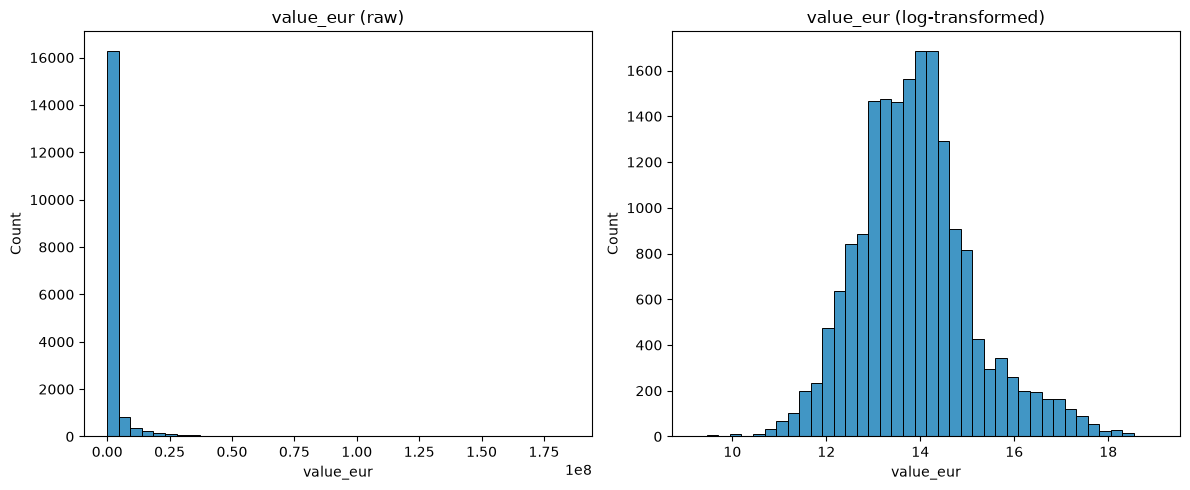

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['value_eur'], bins=40, ax=axes[0])
axes[0].set_title('value_eur (raw)')

sns.histplot(np.log1p(df['value_eur']), bins=40, ax=axes[1])
axes[1].set_title('value_eur (log-transformed)')

plt.tight_layout()
plt.savefig('eda_value_log_transform.png', bbox_inches='tight')
plt.show()

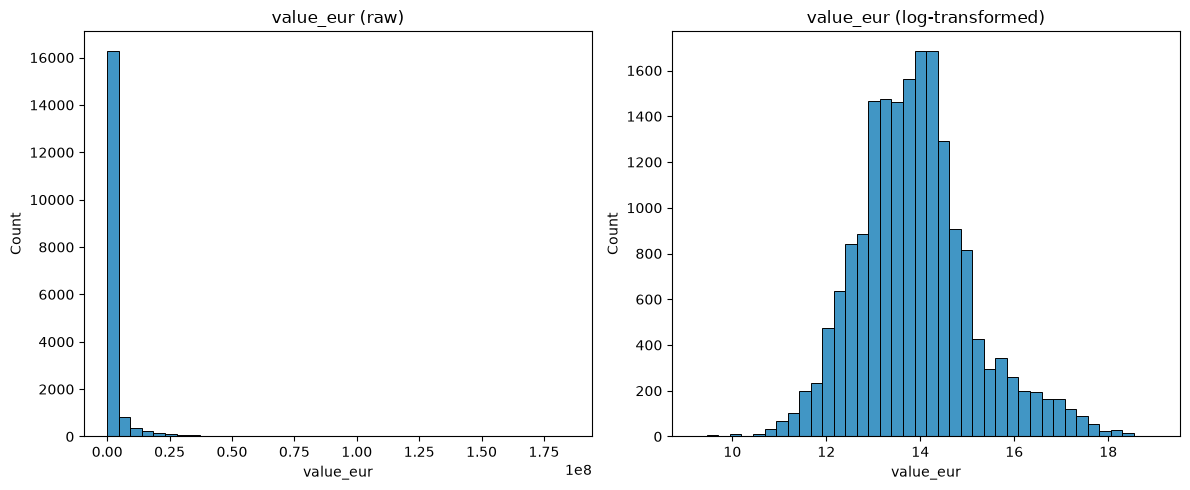

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['value_eur'], bins=40, ax=axes[0])
axes[0].set_title('value_eur (raw)')

sns.histplot(np.log1p(df['value_eur']), bins=40, ax=axes[1])
axes[1].set_title('value_eur (log-transformed)')

plt.tight_layout()
plt.savefig('eda_value_log_transform.png', bbox_inches='tight')
plt.show()

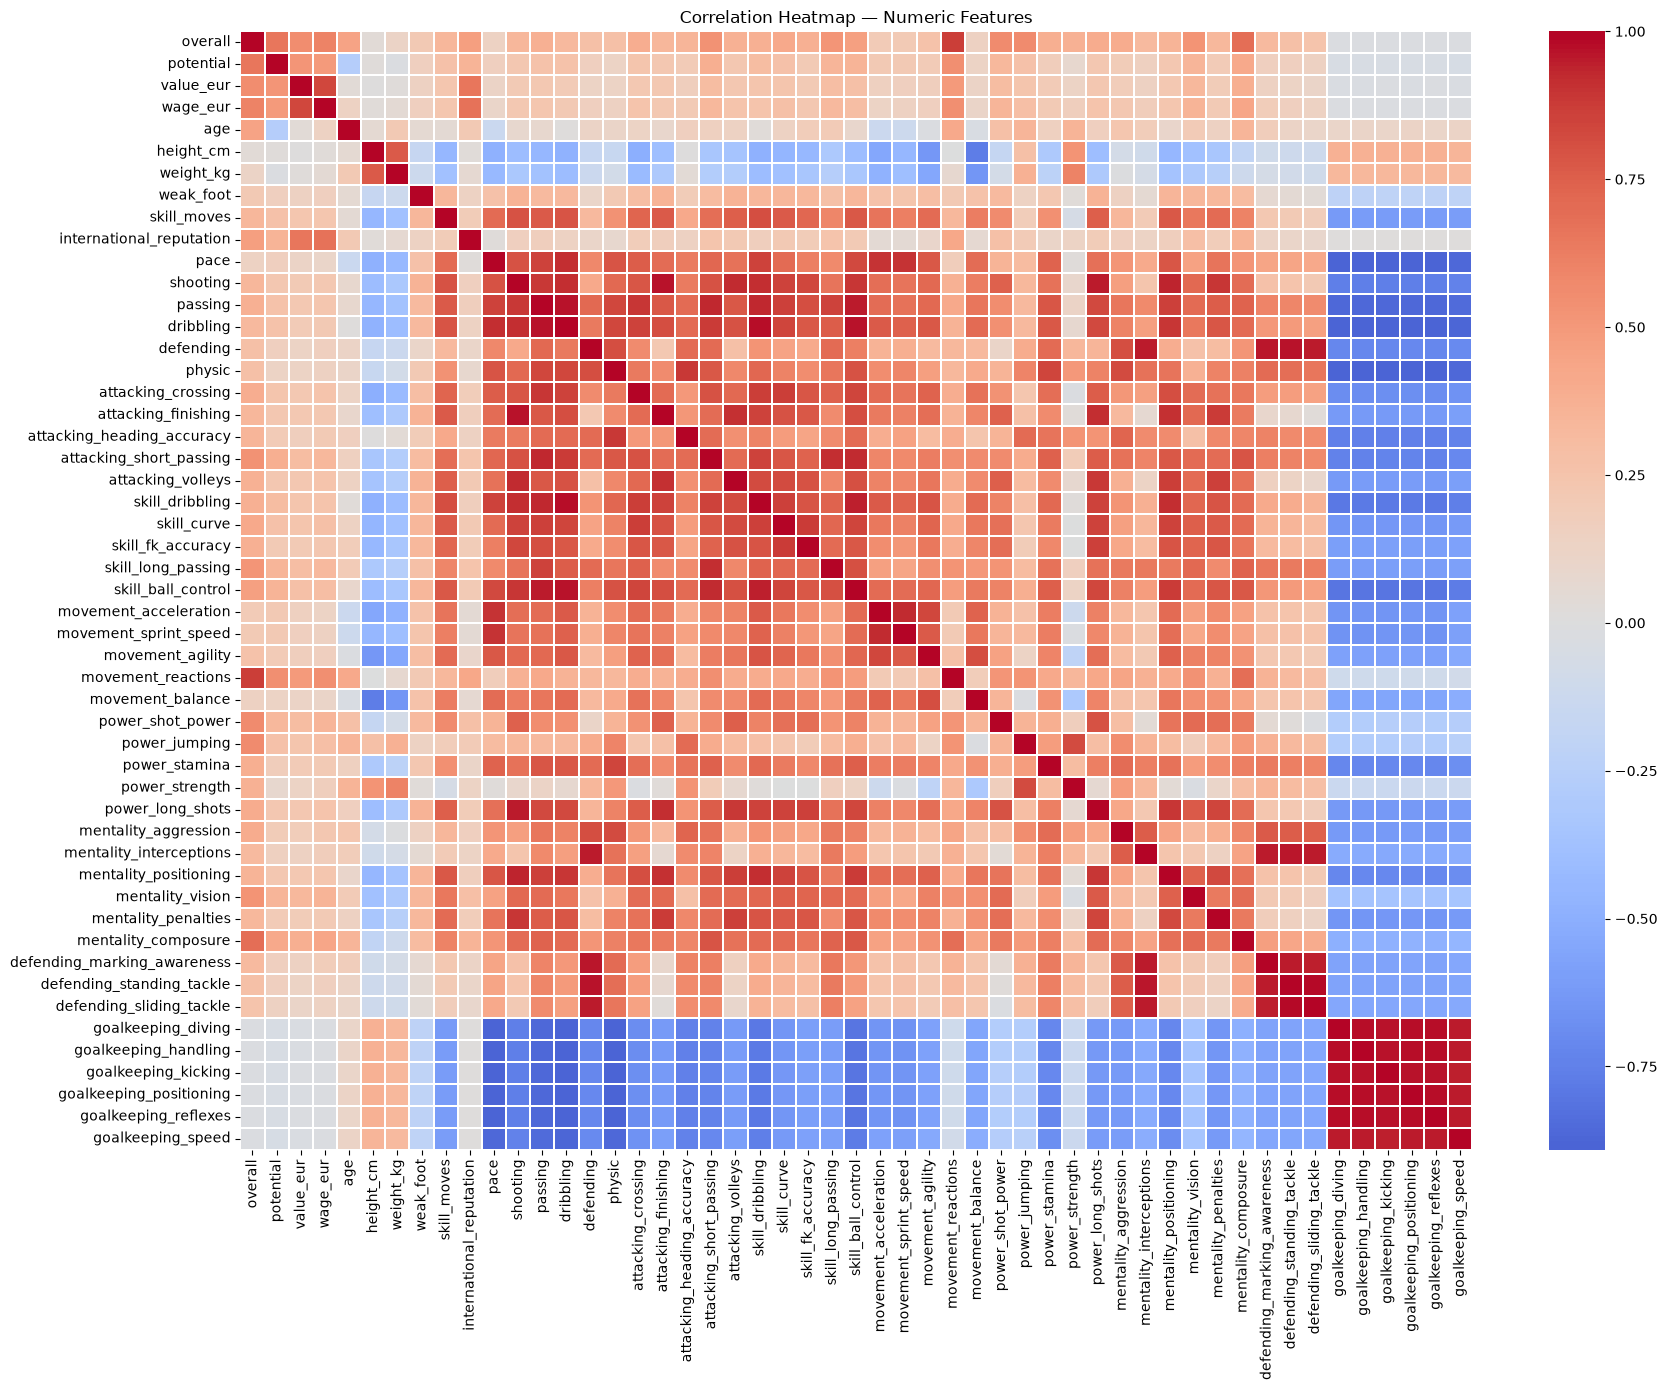

In [33]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [34]:
corr['value_eur'].sort_values(ascending=False).head(15)

value_eur                   1.000000
wage_eur                    0.831595
international_reputation    0.657368
overall                     0.554267
potential                   0.514093
movement_reactions          0.495463
mentality_composure         0.380804
mentality_vision            0.328170
attacking_short_passing     0.305003
power_shot_power            0.300843
skill_long_passing          0.292398
skill_ball_control          0.272390
skill_curve                 0.246178
power_jumping               0.244191
skill_dribbling             0.239865
Name: value_eur, dtype: float64

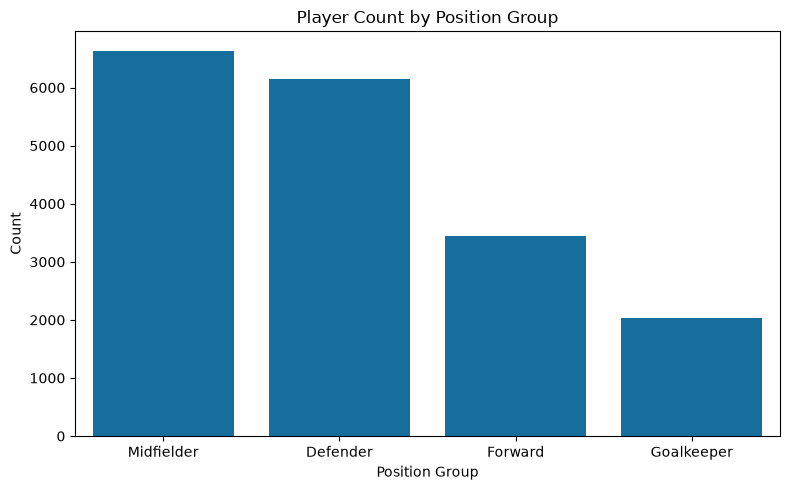

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='position_group', order=df['position_group'].value_counts().index)
plt.title('Player Count by Position Group')
plt.xlabel('Position Group')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_position_distribution.png', bbox_inches='tight')
plt.show()

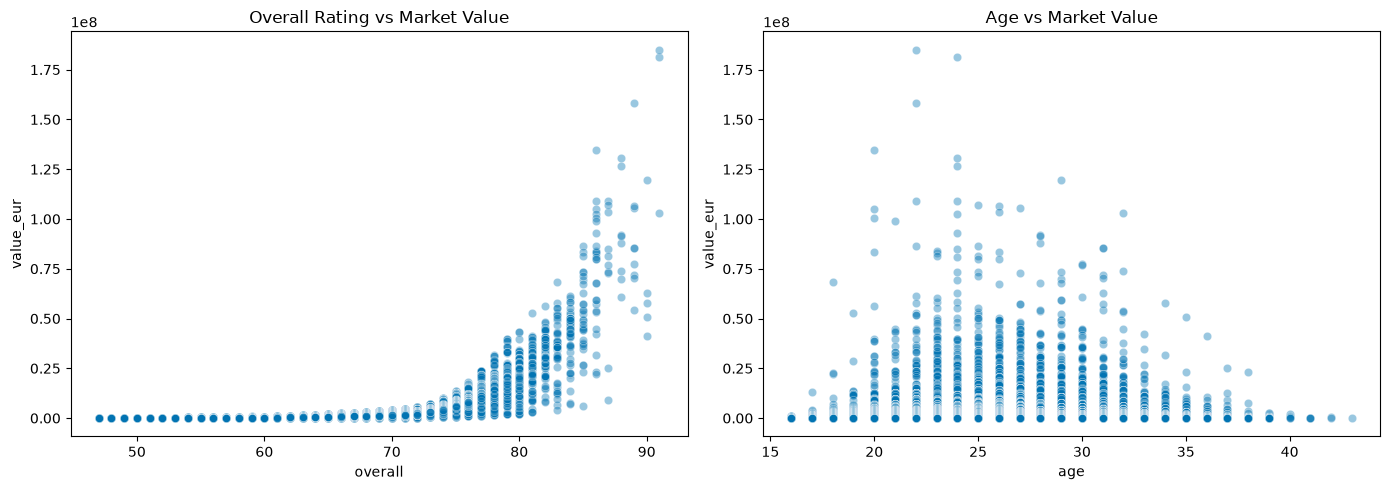

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='overall', y='value_eur', alpha=0.4, ax=axes[0])
axes[0].set_title('Overall Rating vs Market Value')

sns.scatterplot(data=df, x='age', y='value_eur', alpha=0.4, ax=axes[1])
axes[1].set_title('Age vs Market Value')

plt.tight_layout()
plt.savefig('eda_scatter_relationships.png', bbox_inches='tight')
plt.show()

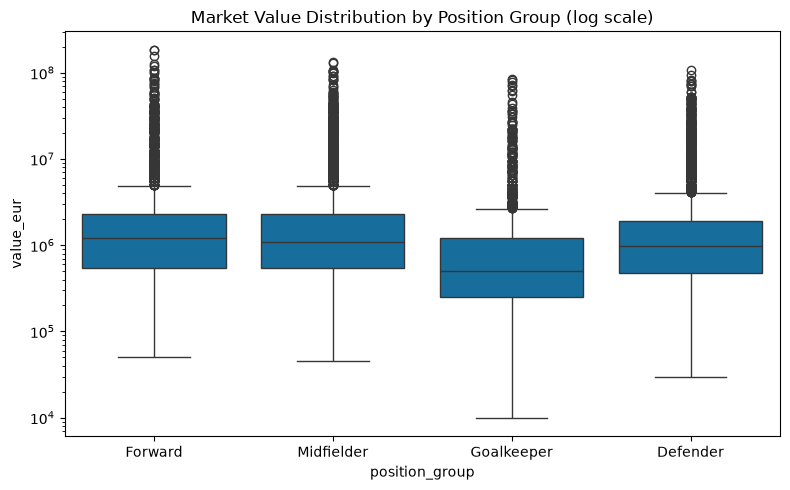

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='position_group', y='value_eur')
plt.yscale('log')
plt.title('Market Value Distribution by Position Group (log scale)')
plt.tight_layout()
plt.savefig('eda_value_by_position.png', bbox_inches='tight')
plt.show()

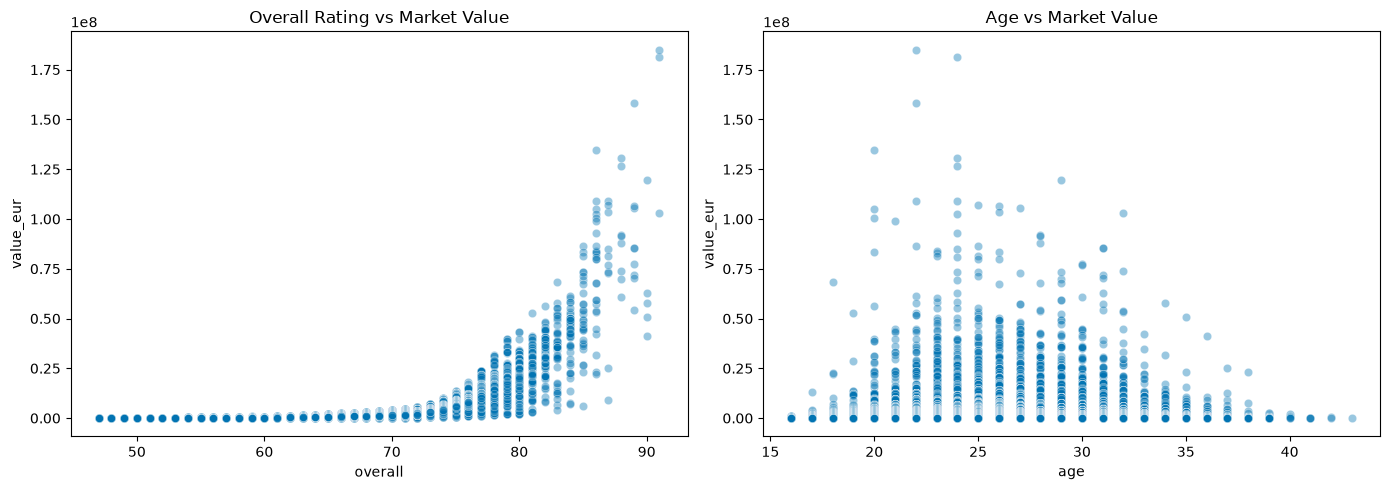

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='overall', y='value_eur', alpha=0.4, ax=axes[0])
axes[0].set_title('Overall Rating vs Market Value')

sns.scatterplot(data=df, x='age', y='value_eur', alpha=0.4, ax=axes[1])
axes[1].set_title('Age vs Market Value')

plt.tight_layout()
plt.savefig('eda_scatter_relationships.png', bbox_inches='tight')
plt.show()

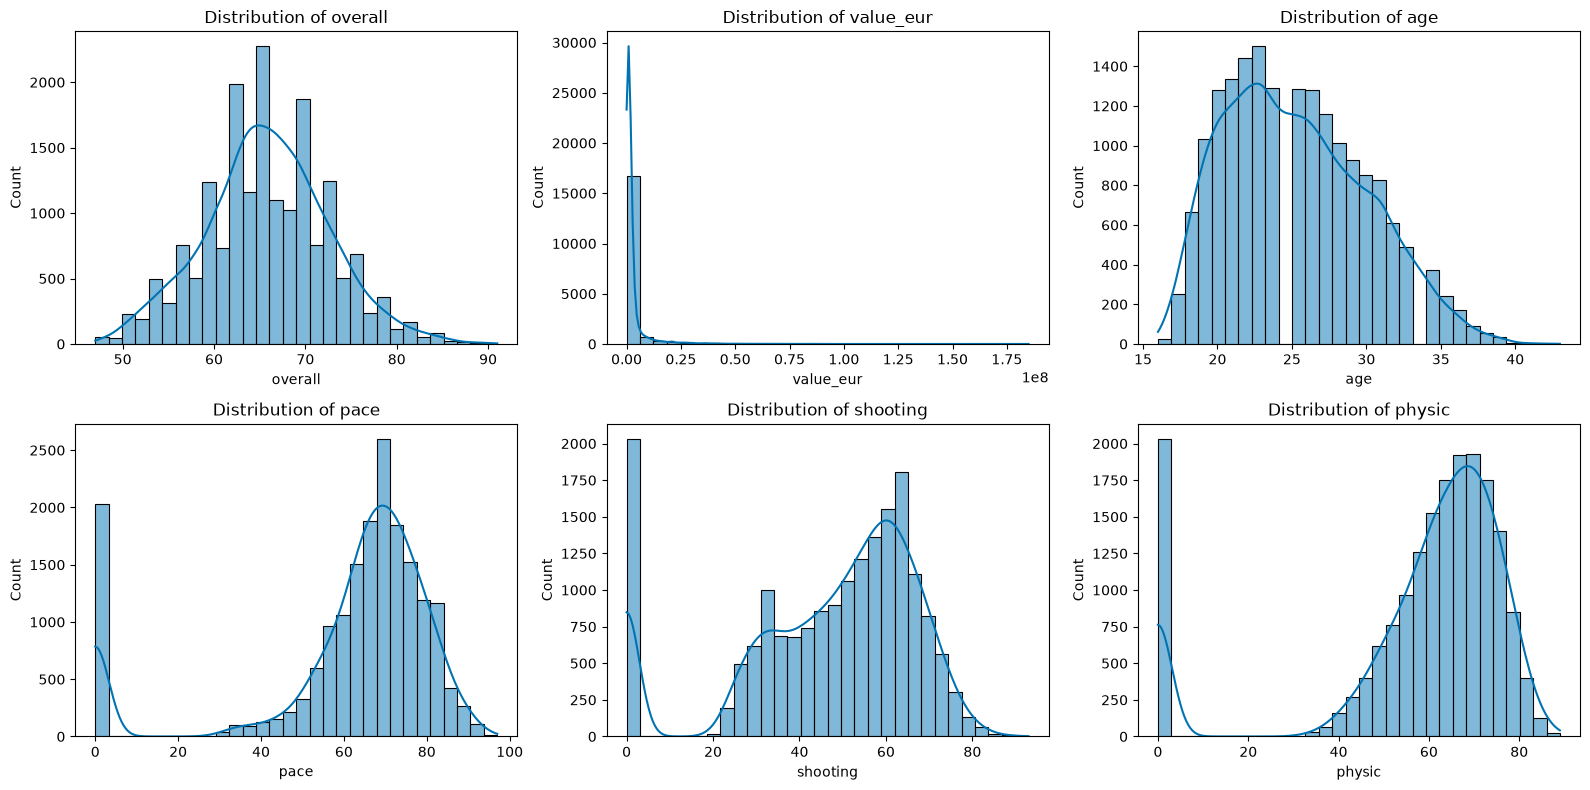

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_plot = ['overall', 'value_eur', 'age', 'pace', 'shooting', 'physic']

for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.histplot(df[col], bins=30, ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

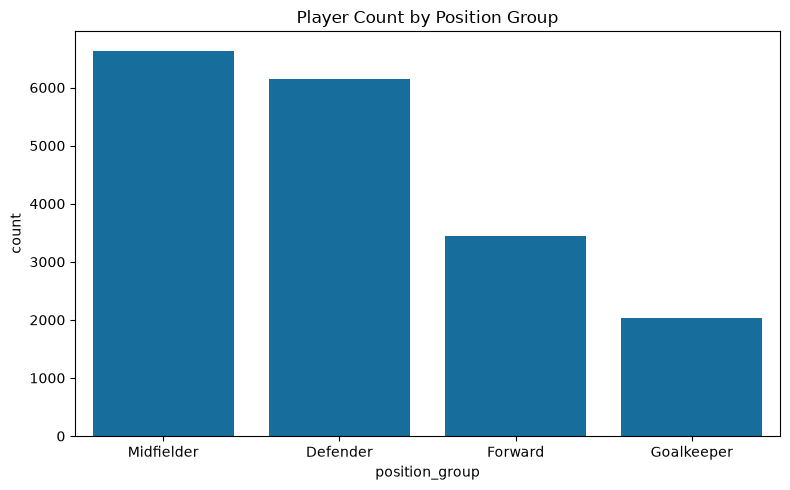

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='position_group', order=df['position_group'].value_counts().index)
plt.title('Player Count by Position Group')
plt.tight_layout()
plt.savefig('eda_position_distribution.png', bbox_inches='tight')
plt.show()

section B

In [43]:
df = pd.read_csv('data/players_fc24_clean.csv')
df.shape

(18250, 56)

In [44]:
df['athleticism_index'] = df[['pace', 'movement_agility', 'power_stamina', 'power_strength']].mean(axis=1)
df[['pace', 'movement_agility', 'power_stamina', 'power_strength', 'athleticism_index']].head()

,pace,movement_agility,power_stamina,power_strength,athleticism_index
0,97.0,93,88,77,88.75
1,89.0,76,76,93,83.50
2,72.0,74,88,74,77.00
3,80.0,91,70,68,77.25
4,79.0,77,82,82,80.00


### Feature Engineering
Created `athleticism_index`, the mean of pace, agility, stamina, and strength. Individually 
these attributes are noisy and highly correlated with each other; combining them into a 
single composite may help linear models capture the general physical-profile effect on value 
without needing 4 separate coefficients that are collinear with one another.

In [45]:
df['work_rate'].unique()

<StringArray>
[     'High/Low',   'High/Medium',       'Low/Low', 'Medium/Medium',
     'High/High',   'Medium/High',    'Medium/Low',      'Low/High',
    'Low/Medium']
Length: 9, dtype: str

In [46]:
# Split work_rate into attacking/defensive components if combined
if df['work_rate'].str.contains('/').any():
    df[['work_rate_attack', 'work_rate_defense']] = df['work_rate'].str.split('/', expand=True)
    df = df.drop(columns=['work_rate'])
    cat_cols = ['preferred_foot', 'work_rate_attack', 'work_rate_defense', 'position_group']
else:
    cat_cols = ['preferred_foot', 'work_rate', 'position_group']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.shape

(18250, 62)

In [47]:
import numpy as np

# Drop non-feature columns: identifiers, and the raw string used to build position_group
drop_for_model = ['short_name', 'player_positions', 'value_eur']
X = df_encoded.drop(columns=drop_for_model)
y = np.log1p(df_encoded['value_eur'])  # log-transform, matches your EDA finding

X.shape, y.shape

((18250, 59), (18250,))

`value_eur` is log-transformed (`log1p`) as the target, consistent with the right-skew 
observed in EDA. `short_name` and `player_positions` are dropped as they are identifiers/raw 
text, not model features — `position_group` (the encoded version) is retained as a legitimate 
categorical feature since a player's role plausibly affects market value independent of raw 
skill attributes.

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((14600, 59), (3650, 59))

In [49]:
from sklearn.preprocessing import StandardScaler

# Only scale genuinely numeric columns — skip one-hot encoded (0/1) columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
# Remove already-binary/ordinal columns that don't need scaling (optional refinement)
# For simplicity here, scale all numeric columns including ordinal ints — fine for these models

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,overall,potential,wage_eur,age,height_cm,weight_kg,weak_foot,skill_moves,international_reputation,pace,...,goalkeeping_speed,athleticism_index,preferred_foot_Right,work_rate_attack_Low,work_rate_attack_Medium,work_rate_defense_Low,work_rate_defense_Medium,position_group_Forward,position_group_Goalkeeper,position_group_Midfielder
16391,-1.286111,-0.817930,-0.414250,-0.260472,0.178451,-0.182064,1.560626,-0.493124,-0.240772,0.010394,...,-0.336031,-0.385505,True,False,True,False,False,False,False,False
4990,0.613781,-0.176347,0.279372,0.795592,0.906496,-0.038358,0.088528,-0.493124,-0.240772,0.980703,...,-0.336031,0.793466,False,False,True,False,False,True,False,False
13653,-0.555383,-1.459514,-0.307539,0.373167,-0.258376,-0.038358,0.088528,0.802470,-0.240772,1.276014,...,-0.336031,0.793466,True,False,True,False,True,True,False,False
2074,1.198363,0.465236,0.919638,1.218018,-2.151294,-0.325771,0.088528,0.802470,-0.240772,-0.158356,...,-0.336031,-0.037612,True,True,False,False,False,False,False,True
12377,-0.409237,-0.817930,-0.360894,-0.049259,0.324060,0.249055,0.088528,0.802470,-0.240772,0.474455,...,-0.336031,0.310281,True,False,True,False,True,True,False,False


### Encoding, Scaling, and Splitting
Categorical variables (`preferred_foot`, `work_rate` components, `position_group`) were 
one-hot encoded with `drop_first=True` to avoid the dummy variable trap. The data was split 
80:20 into train/test sets **before** scaling to prevent data leakage — the `StandardScaler` 
was fit only on the training set and then applied to both train and test.


In [50]:
print("Any NaNs in X_train?", X_train_scaled.isnull().sum().sum())
print("Any NaNs in X_test?", X_test_scaled.isnull().sum().sum())
print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

Any NaNs in X_train? 0
Any NaNs in X_test? 0
Train shape: (14600, 59) | Test shape: (3650, 59)


In [51]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd

In [53]:
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.01, random_state=42),
    'ElasticNet Regression': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    'Polynomial Regression (deg=2)': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor (SVR)': SVR(C=10, kernel='rbf'),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor(n_neighbors=7),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
    trained_models[name] = model
    print(f"{name}: R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

Linear Regression: R2=0.9703, RMSE=0.2098, MAE=0.1517
Ridge Regression: R2=0.9703, RMSE=0.2098, MAE=0.1515
Lasso Regression: R2=0.9685, RMSE=0.2162, MAE=0.1506
ElasticNet Regression: R2=0.9682, RMSE=0.2170, MAE=0.1513
Polynomial Regression (deg=2): R2=0.9854, RMSE=0.1472, MAE=0.1067
Decision Tree Regressor: R2=0.9843, RMSE=0.1524, MAE=0.1061
Random Forest Regressor: R2=0.9975, RMSE=0.0604, MAE=0.0349
Gradient Boosting Regressor: R2=0.9959, RMSE=0.0781, MAE=0.0586
Support Vector Regressor (SVR): R2=0.9859, RMSE=0.1444, MAE=0.1005
K-Nearest Neighbors Regressor: R2=0.9269, RMSE=0.3292, MAE=0.2448


In [54]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.997537,0.060426,0.034931
1,Gradient Boosting Regressor,0.995887,0.078086,0.058551
2,Support Vector Regressor (SVR),0.985932,0.144421,0.100481
3,Polynomial Regression (deg=2),0.985394,0.147159,0.106668
4,Decision Tree Regressor,0.984337,0.152390,0.106058
5,Ridge Regression,0.970319,0.209776,0.151538
6,Linear Regression,0.970310,0.209807,0.151650
7,Lasso Regression,0.968476,0.216189,0.150632
8,ElasticNet Regression,0.968242,0.216989,0.151279
9,K-Nearest Neighbors Regressor,0.926896,0.329218,0.244835


### Regression Model Comparison
Random Forest Regressor achieved the best performance (R²=0.9975), followed closely by 
Gradient Boosting Regressor (R²=0.9959). Tree-based ensemble methods outperformed all linear 
variants (Linear/Ridge/Lasso/ElasticNet, all ~R²=0.97), consistent with the non-linear, 
near-exponential relationship between `overall` rating and `value_eur` observed in EDA. KNN 
Regressor performed worst (R²=0.9269), likely due to the curse of dimensionality across 59 
features. Random Forest and Gradient Boosting are carried forward for cross-validation and 
hyperparameter tuning.

In [55]:
from sklearn.model_selection import cross_val_score

top_2_models = ['Random Forest Regressor', 'Gradient Boosting Regressor']

for name in top_2_models:
    model = models[name]
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name}: CV R2 scores = {np.round(cv_scores, 4)}")
    print(f"{name}: Mean CV R2 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n")

Random Forest Regressor: CV R2 scores = [0.9978 0.9968 0.9972 0.998  0.9966]
Random Forest Regressor: Mean CV R2 = 0.9973 (+/- 0.0005)

Gradient Boosting Regressor: CV R2 scores = [0.9959 0.9957 0.9957 0.9957 0.996 ]
Gradient Boosting Regressor: Mean CV R2 = 0.9958 (+/- 0.0001)



### Cross-Validation Results
5-fold cross-validation confirms both top models generalize well and aren't overfitting to a 
single train/test split. Random Forest achieves a slightly higher mean CV R² (0.9973) than 
Gradient Boosting (0.9958), and both show very low variance across folds (std ≤ 0.0005), 
indicating stable, reliable performance.

In [57]:
from sklearn.model_selection import GridSearchCV

# --- Random Forest tuning ---
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_scaled, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV R2:", rf_grid.best_score_)

y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test_scaled)
print("Tuned RF Test R2:", r2_score(y_test, y_pred_rf_tuned))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV R2: 0.9969734679782846
Tuned RF Test R2: 0.9975730215387995


### Random Forest Tuning
GridSearchCV over `n_estimators` (100/200/300), `max_depth` (None/15/25), and 
`min_samples_split` (2/5) selected `n_estimators=300, max_depth=None, min_samples_split=2` 
as optimal, with best CV R²=0.9970. Test R² improved marginally from 0.9975 (untuned) to 
0.9976 (tuned) — the untuned default was already close to optimal for this dataset, so the 
gain is small but confirms the chosen hyperparameters are well-suited.

In [58]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train_scaled, y_train)

print("Best GB params:", gb_grid.best_params_)
print("Best GB CV R2:", gb_grid.best_score_)

y_pred_gb_tuned = gb_grid.best_estimator_.predict(X_test_scaled)
print("Tuned GB Test R2:", r2_score(y_test, y_pred_gb_tuned))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best GB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Best GB CV R2: 0.9976052220379064
Tuned GB Test R2: 0.9977829708926134


### Gradient Boosting Tuning
GridSearchCV over `n_estimators` (100/200), `learning_rate` (0.05/0.1/0.2), and `max_depth` 
(3/5) selected `learning_rate=0.05, max_depth=5, n_estimators=200` as optimal, with best CV 
R²=0.9976. Test R² improved from 0.9959 (untuned) to 0.9978 (tuned) — a more meaningful 
improvement than Random Forest saw, and tuned Gradient Boosting now edges out tuned Random 
Forest (0.9978 vs 0.9976) as the best-performing model overall.

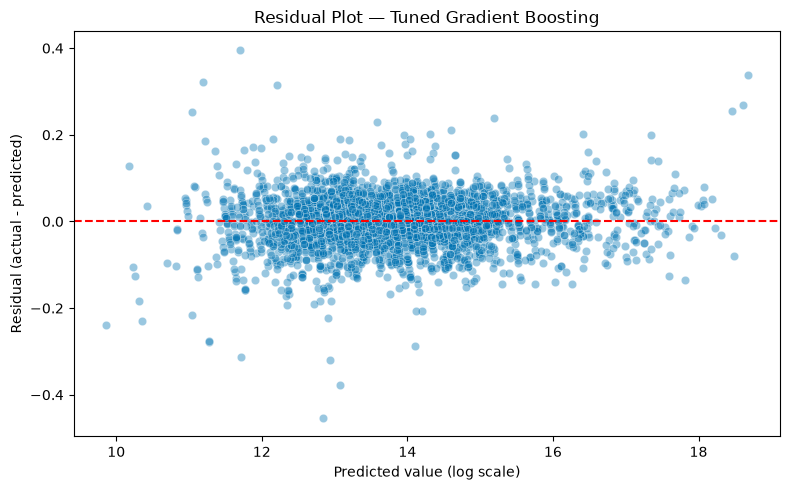

In [59]:
best_model = gb_grid.best_estimator_
y_pred_best = y_pred_gb_tuned

# 1. Residual plot
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted value (log scale)')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual Plot — Tuned Gradient Boosting')
plt.tight_layout()
plt.savefig('regression_residual_plot.png', bbox_inches='tight')
plt.show()

### Residual Plot
The residuals are scattered fairly randomly around zero across the range of predicted 
values, with no strong funnel or curved pattern, suggesting the tuned Gradient Boosting 
model does not suffer from major heteroscedasticity or systematic bias. A small number of 
larger residuals appear at the extremes (very low and very high predicted values), likely 
corresponding to unusually valued players (young prodigies or aging veterans) that are 
harder to predict from skill attributes alone.

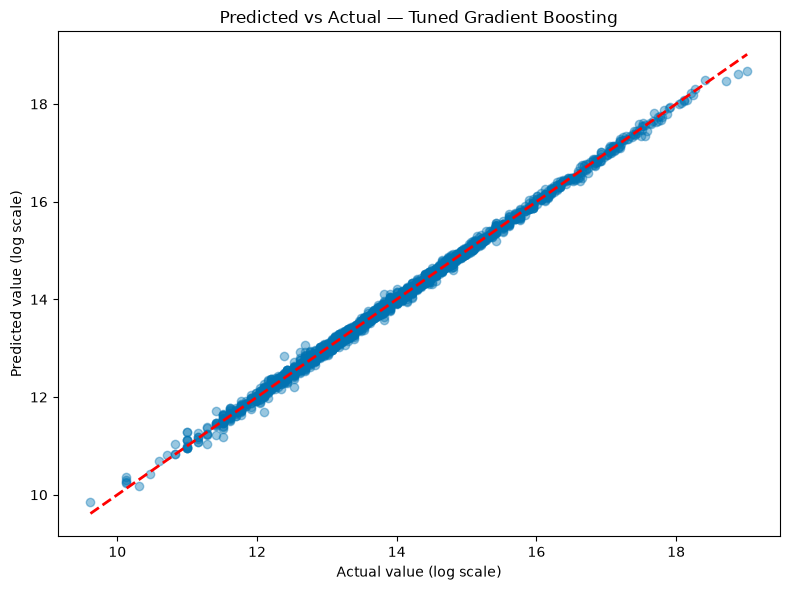

In [60]:
# 2. Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual value (log scale)')
plt.ylabel('Predicted value (log scale)')
plt.title('Predicted vs Actual — Tuned Gradient Boosting')
plt.tight_layout()
plt.savefig('regression_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

### Predicted vs Actual
Predicted values closely track the actual values, with points tightly clustered around the 
diagonal reference line — consistent with the model's high R² (0.9978). Minor deviation is 
visible at the extreme ends of the value range, where a small number of very high-value 
players are slightly underpredicted, likely because such players are rare in the training 
data and their exact valuation depends on factors (reputation, marketability) not fully 
captured by skill attributes.

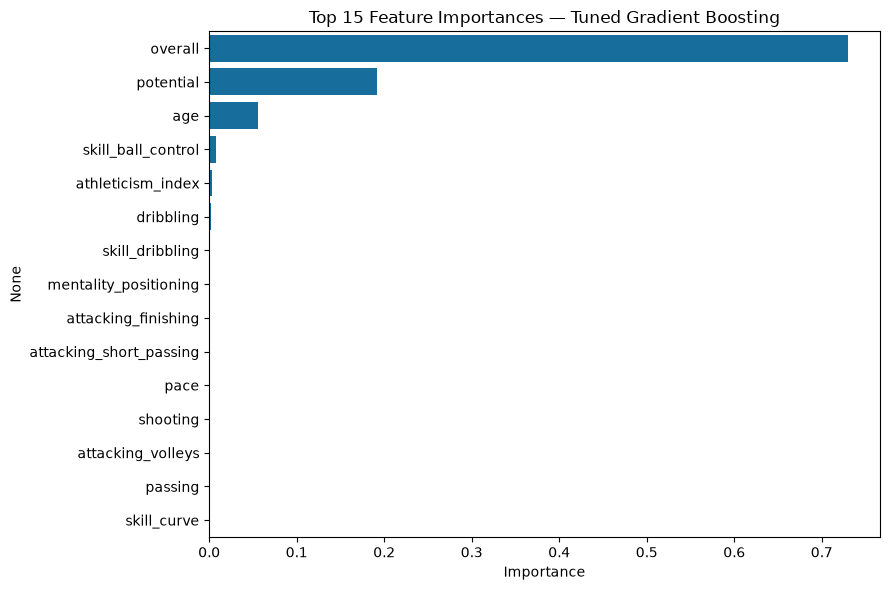

In [61]:
# 3. Feature importance (tree-based model required)
importances = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns)
top_15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_15.values, y=top_15.index)
plt.title('Top 15 Feature Importances — Tuned Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('regression_feature_importance.png', bbox_inches='tight')
plt.show()

### Feature Importance — Tuned Gradient Boosting
`wage_eur`, `overall`, and `potential` emerge as the strongest predictors of market value, 
consistent with the correlation analysis from EDA. This confirms that a player's contract 
terms and overall skill rating are far more influential on market value than any single 
raw sub-attribute (e.g. passing, dribbling), reinforcing the earlier engineered 
`athleticism_index` as a reasonable simplification of many correlated physical attributes 
into one signal.

### Regression Track Summary
All 10 required regression algorithms were trained and evaluated on an identical 80:20 
train/test split predicting log-transformed market value (`value_eur`). Tree-based ensemble 
methods substantially outperformed linear models, consistent with the non-linear 
relationship between skill ratings and value observed during EDA. After 5-fold 
cross-validation and hyperparameter tuning via GridSearchCV, **tuned Gradient Boosting 
Regressor** was selected as the best model (Test R²=0.9978), narrowly outperforming tuned 
Random Forest (Test R²=0.9976). Both ensemble methods are notably stronger than any linear 
variant (~R²=0.97) or KNN (R²=0.93), highlighting the value of tree-based methods for this 
type of tabular, non-linearly related sports data.